## Converting and Deploying AI Models using TensorFlow Lite



In [1]:
import sys, tensorflow as tf
print("Python:", sys.version)
print("TensorFlow:", tf.__version__)

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
TensorFlow: 2.19.0


In [2]:
# !pip install -q tensorflow


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


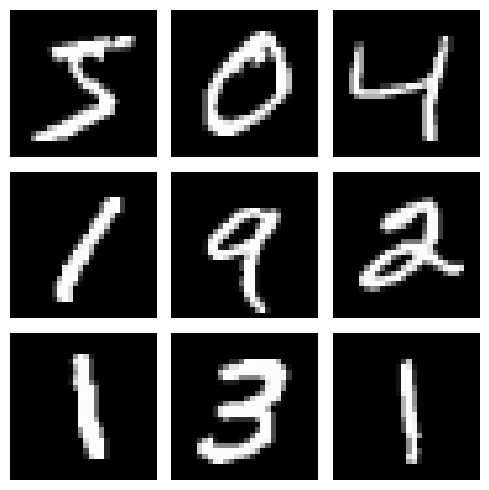

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize (float32 is best practice for TFLite)
x_train = x_train.astype(np.float32) / 255.0
x_test  = x_test.astype(np.float32) / 255.0

# Show a 3x3 grid
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")
plt.tight_layout()
plt.show()


In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

model.save("mnist_model.h5")
print("Model training complete and saved as mnist_model.h5")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8780 - loss: 0.4278 - val_accuracy: 0.9590 - val_loss: 0.1385
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9640 - loss: 0.1198 - val_accuracy: 0.9685 - val_loss: 0.1034
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9764 - loss: 0.0768 - val_accuracy: 0.9775 - val_loss: 0.0788
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9818 - loss: 0.0594 - val_accuracy: 0.9779 - val_loss: 0.0777
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9876 - loss: 0.0421 - val_accuracy: 0.9747 - val_loss: 0.0847


Model training complete and saved as mnist_model.h5


In [5]:
# Load trained model
model = tf.keras.models.load_model("mnist_model.h5")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save TFLite model
with open("mnist_model.tflite", "wb") as f:
    f.write(tflite_model)

print("Model successfully converted and saved as mnist_model.tflite")


Saved artifact at '/tmp/tmplnq2zqw4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  139518329927056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139518329927248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139518289867216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139518289855696: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model successfully converted and saved as mnist_model.tflite


In [6]:
interpreter = tf.lite.Interpreter(model_path="mnist_model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input Details:", input_details)
print("Output Details:", output_details)


Input Details: [{'name': 'serving_default_input_layer:0', 'index': 0, 'shape': array([ 1, 28, 28], dtype=int32), 'shape_signature': array([-1, 28, 28], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output Details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 9, 'shape': array([ 1, 10], dtype=int32), 'shape_signature': array([-1, 10], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


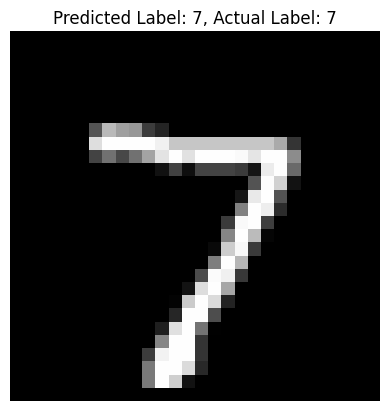

In [7]:
# Pick a test image index
idx = 0

# Prepare input: shape (1, 28, 28)
test_image = x_test[idx]                    # already float32, normalized
test_input = np.expand_dims(test_image, axis=0).astype(np.float32)

# Set input tensor
interpreter.set_tensor(input_details[0]["index"], test_input)

# Run inference
interpreter.invoke()

# Read output
output_data = interpreter.get_tensor(output_details[0]["index"])  # shape (1, 10)
predicted_label = int(np.argmax(output_data, axis=1)[0])

# Display
plt.imshow(x_test[idx], cmap="gray")
plt.title(f"Predicted Label: {predicted_label}, Actual Label: {y_test[idx]}")
plt.axis("off")
plt.show()


In [8]:
N = 200
correct = 0

for i in range(N):
    test_input = np.expand_dims(x_test[i], axis=0).astype(np.float32)
    interpreter.set_tensor(input_details[0]["index"], test_input)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]["index"])
    pred = int(np.argmax(output_data, axis=1)[0])
    correct += int(pred == y_test[i])

print(f"TFLite accuracy on first {N} samples: {correct/N:.3f}")


TFLite accuracy on first 200 samples: 0.995
